# Does the three-state head actually discriminate N, P and U?

`part_4`/`part_6` measure the two `predictive_expanded`-grid N/P/U conditions
(`pnu_ce` = `ThreeStateCrossEntropyLoss`, `observed_pnu_cross_entropy` =
`ObservedPNUSCrossEntropyLoss`) only through their *ranking* score
(`average_precision`/`roc_auc`, from `positive_scores`' softmax-positive reduction) and
through `state_separation`'s continuous P-vs-U/N-vs-U AUCs (`part_4`). Neither answers
the question a three-state head is actually built to answer: does its own hard N/P/U
decision (`argmax` over the softmax) separate a true operational negative N from a true
unlabelled U, or does it collapse the two into whichever state happens to be more
common? This notebook answers that directly, per condition, with the head's own
discrete decision — not a continuous proxy for it.

## Introduction

For every class and every available entry, `heads.predictive_comparison.state_confusion`
cross-tabulates the true evidence state (the label the shared evidence policy assigned,
`part_0_2`) against the head's own predicted state (`argmax` over its N/P/U softmax),
per class, as a 3x3 contingency table (`state_confusion`) plus, per class, `argmax`
accuracy, the trivial majority-class baseline it should beat, and a chi-square
independence test between true and predicted state (`state_confusion_summary`). This is
a genuinely separate question from ranking quality: a head can rank P above U above N
almost perfectly (high `state_separation` AUCs) while its *hard* decision still
routinely mislabels N as U, if its decision boundary sits in the wrong place — ranking
and calibration are independent properties of a score.

### Assumptions

- **Discrimination is checked against a majority-class baseline, not chance at 1/3.**
  The evidence policy makes P and N genuinely rarer than U for almost every class (most
  pixels are unlabelled), so a trivial "always predict U" rule already scores well above
  1/3 accuracy; only doing better than that rule is informative evidence that the head
  actually uses its input, rather than having learned the class-prior shortcut.
- **The chi-square test is per class, uncorrected.** With up to several hundred classes
  and two conditions, a handful of classes crossing p<0.05 by chance is expected; the
  headline evidence is the pooled effect size (the Cramér's V distribution and the
  accuracy-vs-baseline gap), not the raw count of "significant" classes.
- **Only `pnu_ce` and `observed_pnu_cross_entropy` are in scope.** Every other condition
  in this campaign makes a binary decision (see `part_4`'s "Threshold-based prediction
  metrics" section for exactly which loss families qualify and why); a three-way
  confusion table is undefined for them, and `state_confusion` raises if given anything
  but N/P/U-shaped logits.
- **Five repetitions per condition bound seed noise, not the population**, same as
  `part_4`.

### Notation

For class $k$, condition $c$, split $s$, and states $N, P, U$: $T_k(N)$ is the number of
entries truly N; $\hat T_k(N \to p)$ is how many of those the head's `argmax` places in
predicted state $p \in \{N, P, U\}$, so $\sum_p \hat T_k(N \to p) = T_k(N)$ exactly — the
row-sum identity the pooled table below shows directly, not merely asserts. $M_{k}[t, p]
= \hat T_k(t \to p)$ is the class's full $3 \times 3$ contingency table (true state $t$,
predicted state $p$), and $n_k = \sum_{t,p} M_k[t,p]$ its total entries.

**Accuracy and the majority baseline** (`state_confusion_summary.accuracy`/
`majority_baseline_accuracy`): $\mathrm{accuracy}_k = \mathrm{tr}(M_k) / n_k$ (the
`argmax` decision agrees with the true state); $\mathrm{baseline}_k =
\max_t\big(\sum_p M_k[t,p]\big) / n_k$ — the accuracy of a rule that ignores the input
entirely and always predicts class $k$'s own single most common true state. The
"existence" quantity plotted below is $\mathrm{accuracy}_k - \mathrm{baseline}_k$: zero
or negative means the head's three-way decision adds nothing over that trivial,
input-free rule.

**Chi-square independence test and Cramér's V** (`state_confusion_summary.chi2_statistic`/
`chi2_p_value`/`cramers_v`, `scipy.stats.chi2_contingency` on $M_k$ with empty
rows/columns dropped first): under the null hypothesis that predicted state is
independent of true state, $\chi^2_k = \sum_{t,p} (M_k[t,p] - E_k[t,p])^2 / E_k[t,p]$,
where $E_k[t,p] = (\text{row } t \text{ total})(\text{column } p \text{ total}) / n_k$ is
the expected count under independence. `chi2_p_value` is this statistic's upper-tail
p-value against the appropriate $\chi^2$ distribution — small values reject
independence, i.e. the predicted state does track the true state. Cramér's V rescales
the same statistic into an effect size on $[0, 1]$, comparable across classes with
different entry counts and table shapes: $V_k = \sqrt{(\chi^2_k / n_k) /
(\min(r_k, c_k) - 1)}$, where $r_k$, $c_k$ are the numbers of true/predicted states
actually observed for that class (after dropping empty rows/columns) — undefined
(`NaN`) whenever fewer than two true or two predicted states are observed, since no
contingency table exists to test.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import predictive_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments import predictive_precompute as cache
from msi_autoencoder_wrapper.analysis.autoencoder.heads.predictive_comparison import THREE_STATE_FAMILIES
from msi_autoencoder_wrapper.utils.logger import get_custom_logger
from msi_autoencoder_wrapper.visualization import resolve_theme
from msi_autoencoder_wrapper.visualization.metrics import plot_violin_with_points

logger = get_custom_logger("pnu_state_discrimination")

2026-09-19 17:00:38,418 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-09-19 17:00:38,420 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


2026-09-19 17:00:38,861 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.


2026-09-19 17:00:38,864 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 28 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.


2026-09-19 17:00:38,873 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.


2026-09-19 17:00:38,875 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 46 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-09-19 17:00:38,896 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.models.datasets.strategies'.


2026-09-19 17:00:38,913 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions.autoencoder'.


2026-09-19 17:00:38,914 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 33 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions'.


## Configuration

## Producing the tables this notebook reads

### Methodology

#### Implementation

No new precompute routine backs this notebook: `state_confusion` and
`state_confusion_summary` are already written by the base full-campaign inference cache
(`predictive_precompute.precompute`), for every model — the two three-state conditions
get real rows, every other condition writes the same table shape with zero rows (see
`precompute`'s own comment on why: keeps `load_table` free to assume every model has
every table file). This notebook only reads and derives cheap summaries.

If those tables are missing, `predictive_precompute.load_table` names the base
precompute command that produces them.

### Remarks

### Notes

In [2]:
SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/14_09_predictive_expanded/analysis_settings.yaml")
NOTEBOOK_DIR = SETTINGS_PATH.parent
RESULTS = NOTEBOOK_DIR / "part_8_pnu_state_discrimination_results"
RESULTS.mkdir(exist_ok=True)

settings = campaign.load_settings(SETTINGS_PATH)

theme = resolve_theme(None)
theme.apply()

# --- embedded figure resolution --------------------------------------------
FIGURE_RASTER_DPI = 100
plt.rcParams["savefig.dpi"] = FIGURE_RASTER_DPI
# ---------------------------------------------------------------------------

In [3]:
models, _ = campaign.inventory(settings)
ready = models[models.ready]
pnu_ready = ready[ready.family.isin(THREE_STATE_FAMILIES)]

state_confusion = cache.load_table(settings, "state_confusion")
state_confusion_summary = cache.load_table(settings, "state_confusion_summary")

CONDITION_ORDER = sorted(pnu_ready.label.unique())
LABEL_COLOR = {label: theme.color_for_model(label, index) for index, label in enumerate(CONDITION_ORDER)}
SPLIT = "test"
POOLED_STATE_ORDER = ["N", "P", "U"]

print(f"{pnu_ready.model_id.nunique()} three-state model(s) across {len(CONDITION_ORDER)} condition(s): {CONDITION_ORDER}")
print(f"{len(state_confusion)} confusion row(s) (every other condition contributes none), "
     f"{len(state_confusion_summary)} per-class summary row(s)")

2026-09-19 17:00:49,484 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.predictive_campaign:311 | Audited 120 model manifests across 4 sources.


15 three-state model(s) across 2 condition(s): ['observed_pnu_cross_entropy (ObservedPNUSCrossEntropyLoss)', 'pnu_ce (ThreeStateCrossEntropyLoss)']
205740 confusion row(s) (every other condition contributes none), 22860 per-class summary row(s)


## Pooled N/P/U confusion: what was truly there vs. what the head predicts

### Methodology

#### Theoretical

The direct answer to "how many entries were truly negative, how many does the head
predict, and how does that relate to unlabelled" is a 3x3 contingency table, pooled
(summed) over every class and repetition rather than averaged: a sum answers "how many
objects", an average answers "what fraction of a typical class" — the sum is what was
asked. Each row's total is exactly the true-state count (the row-sum identity in the
Notation above), shown as its own column so the audit is visible, not asserted.

#### Implementation

`state_confusion`, evaluation split, summed `count` grouped by `(label, true_state,
predicted_state)` across every class and repetition. The row-normalized version (share
of each true state predicted as each state) is shown as a heatmap for readability; the
raw counts are the table above it.

#### Figure descriptions

Table: one 3x3 count matrix per condition, rows true state, columns predicted state,
plus a `total` column. Heatmap: the same matrices row-normalized to `[0, 1]`, annotated
with the share in each cell.

### Remarks

### Notes

In [4]:
pooled_long = (
    state_confusion.query("split == @SPLIT and label in @CONDITION_ORDER")
    .groupby(["label", "true_state", "predicted_state"], observed=True)["count"].sum()
    .reset_index()
)

pooled_tables = {}
for label in CONDITION_ORDER:
    matrix = (
        pooled_long.query("label == @label")
        .pivot(index="true_state", columns="predicted_state", values="count")
        .reindex(index=POOLED_STATE_ORDER, columns=POOLED_STATE_ORDER)
        .fillna(0)
        .astype(int)
    )
    matrix["total (true-state count)"] = matrix.sum(axis=1)
    pooled_tables[label] = matrix
    print(label)
    display(matrix)

observed_pnu_cross_entropy (ObservedPNUSCrossEntropyLoss)


predicted_state,N,P,U,total (true-state count)
true_state,,,,
N,3763761,11978,297646,4073385
P,14435,463321,49454,527210
U,308738,67105,5704262,6080105


pnu_ce (ThreeStateCrossEntropyLoss)


predicted_state,N,P,U,total (true-state count)
true_state,,,,
N,7498183,25553,623034,8146770
P,27078,929342,98000,1054420
U,591909,136927,11431374,12160210


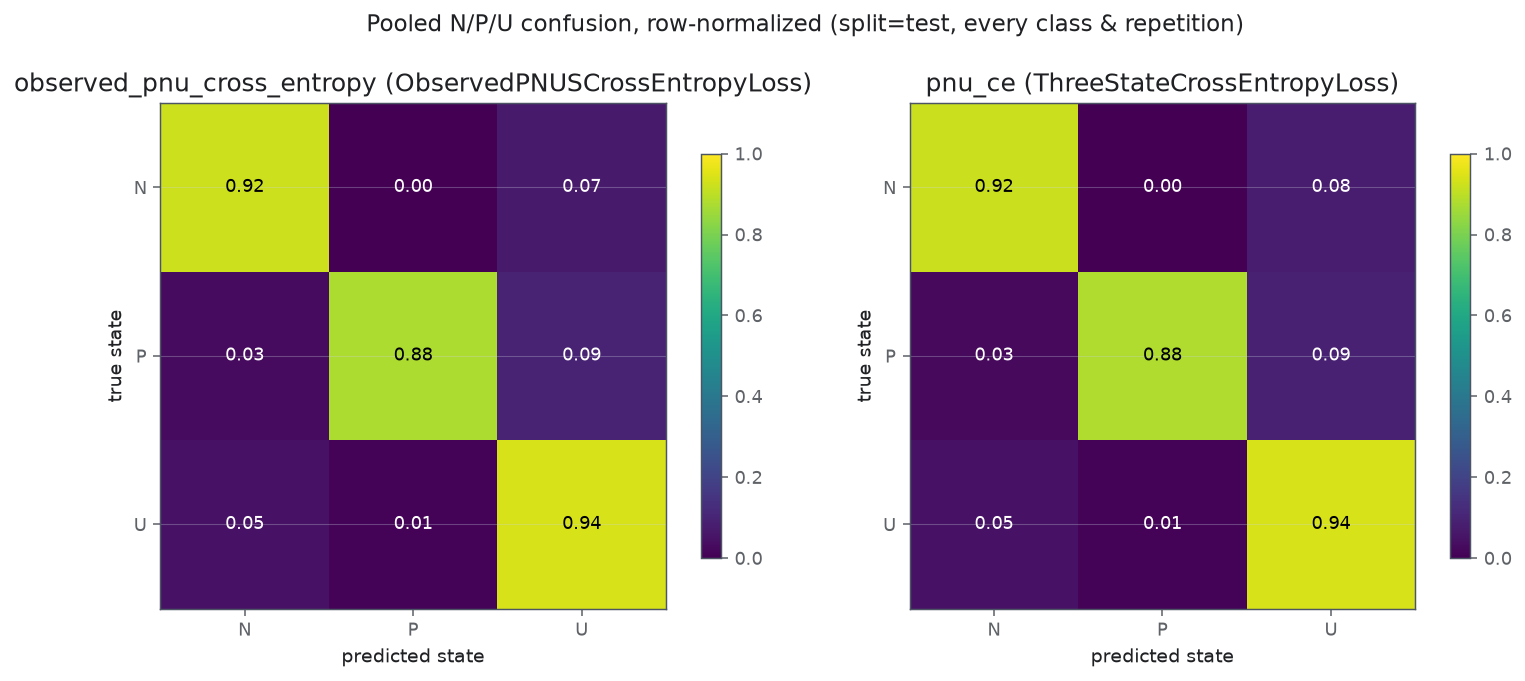

In [5]:
figure, axes = plt.subplots(1, len(CONDITION_ORDER), figsize=(5.5 * len(CONDITION_ORDER), 4.5), dpi=theme.figure_dpi, squeeze=False)
for axis, label in zip(axes[0], CONDITION_ORDER):
    matrix = pooled_tables[label][POOLED_STATE_ORDER]
    share = matrix.div(matrix.sum(axis=1), axis=0)
    image = axis.imshow(share.to_numpy(), vmin=0, vmax=1, cmap="viridis")
    axis.set_xticks(range(3))
    axis.set_xticklabels(POOLED_STATE_ORDER)
    axis.set_yticks(range(3))
    axis.set_yticklabels(POOLED_STATE_ORDER)
    axis.set(xlabel="predicted state", ylabel="true state", title=label)
    for row in range(3):
        for column in range(3):
            value = share.iloc[row, column]
            axis.text(column, row, f"{value:.2f}", ha="center", va="center",
                     color="white" if value < 0.5 else "black", fontsize=9)
    figure.colorbar(image, ax=axis, shrink=0.8)
figure.suptitle(f"Pooled N/P/U confusion, row-normalized (split={SPLIT}, every class & repetition)", y=1.03)
figure.tight_layout()

## Existence check: does the decision beat the trivial baseline?

### Methodology

#### Theoretical

A per-class chi-square test of independence between true and predicted state asks
whether the head's decision tracks the true state at all; Cramér's V is its effect
size, in `[0, 1]`, comparable across classes with different entry counts. Accuracy minus
the majority-class baseline accuracy (always predicting the class's own most common
true state) is a more interpretable, model-free way to ask the same "does discrimination
exist" question: zero or negative means the head's three-way decision adds nothing over
just knowing the class's label distribution.

#### Implementation

`state_confusion_summary`, evaluation split, averaged over repetitions per class. Both
the accuracy gap and Cramér's V are shown as full per-class distributions, not only
their means, for the same reason every other distribution in this campaign is shown in
full (`part_4`).

#### Figure descriptions

Left: per condition, the distribution over classes of (argmax accuracy − majority
baseline accuracy); the dotted line at zero is "no better than the trivial rule". Right:
the same, for Cramér's V (unsigned effect size, no zero line).

### Remarks

### Notes

In [6]:
class_summary = (
    state_confusion_summary.query("split == @SPLIT and label in @CONDITION_ORDER")
    .groupby(["label", "class_index", "class_name"], as_index=False)
    .agg(entries=("entries", "mean"), accuracy=("accuracy", "mean"),
        majority_baseline_accuracy=("majority_baseline_accuracy", "mean"),
        cramers_v=("cramers_v", "mean"), chi2_p_value=("chi2_p_value", "mean"))
)
class_summary["accuracy_above_baseline"] = class_summary.accuracy - class_summary.majority_baseline_accuracy

for label in CONDITION_ORDER:
    subset = class_summary.query("label == @label")
    testable = subset.chi2_p_value.notna()
    significant = testable & (subset.chi2_p_value < 0.05)
    print(f"{label}: {len(subset)} class(es); {testable.sum()} testable (>=2 true and "
         f"predicted states observed), {significant.sum()} ({significant.mean():.1%} of "
         "all classes) significant at p<0.05 uncorrected; median accuracy "
         f"{subset.accuracy.median():.3f} vs. median majority baseline "
         f"{subset.majority_baseline_accuracy.median():.3f}")

observed_pnu_cross_entropy (ObservedPNUSCrossEntropyLoss): 508 class(es); 508 testable (>=2 true and predicted states observed), 508 (100.0% of all classes) significant at p<0.05 uncorrected; median accuracy 0.938 vs. median majority baseline 0.611
pnu_ce (ThreeStateCrossEntropyLoss): 508 class(es); 508 testable (>=2 true and predicted states observed), 508 (100.0% of all classes) significant at p<0.05 uncorrected; median accuracy 0.938 vs. median majority baseline 0.611


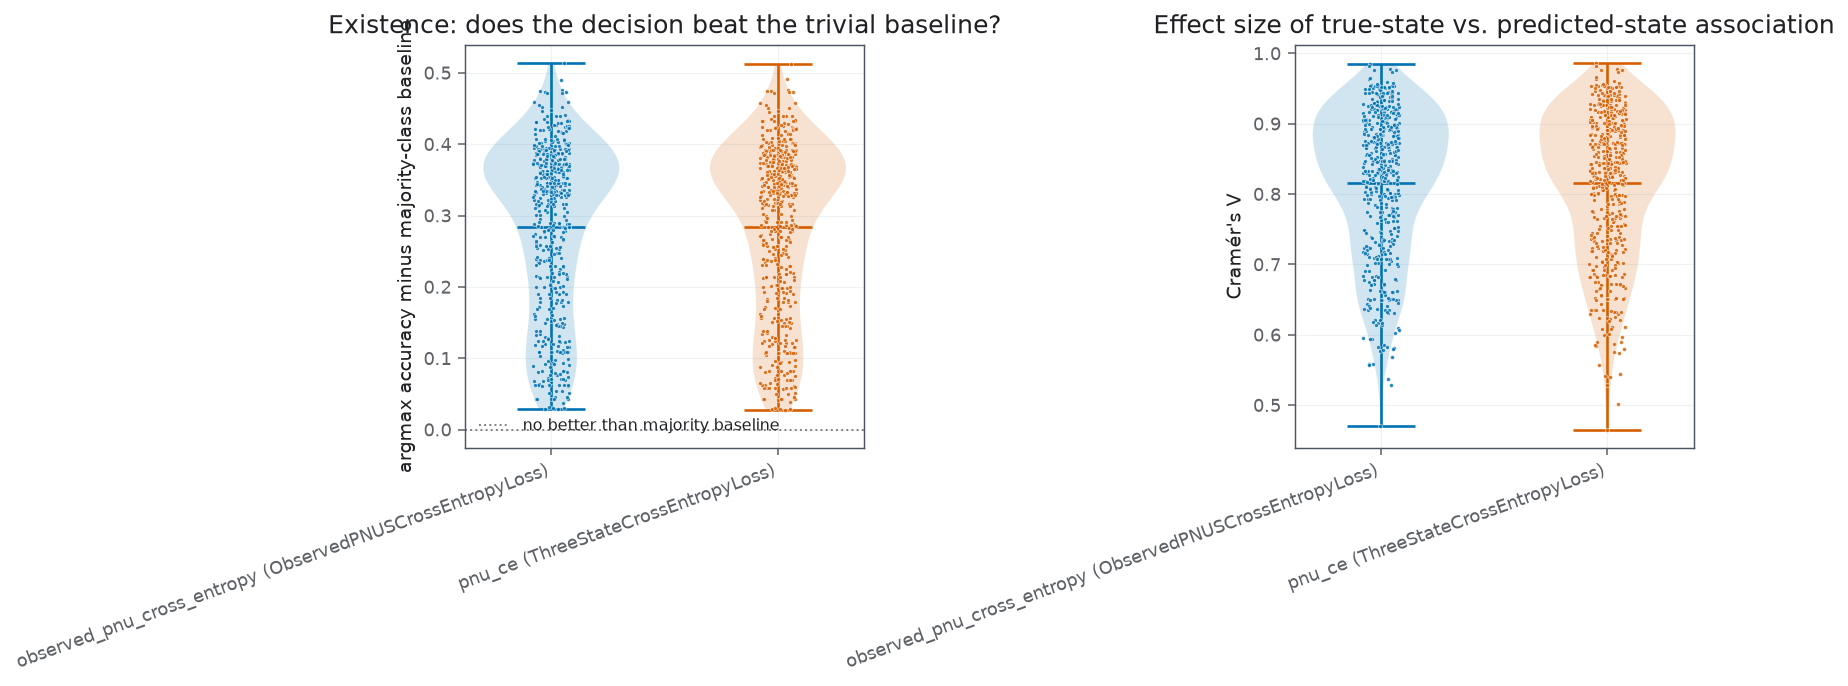

In [7]:
figure, (accuracy_axis, cramers_axis) = plt.subplots(1, 2, figsize=(12.0, 5.0), dpi=theme.figure_dpi)
for position, label in enumerate(CONDITION_ORDER):
    subset = class_summary.query("label == @label")
    plot_violin_with_points(subset.accuracy_above_baseline.dropna().to_numpy(), position=position,
                            ax=accuracy_axis, width=0.6, color=LABEL_COLOR[label], point_size=4.0,
                            jitter=0.08, theme=theme)
    plot_violin_with_points(subset.cramers_v.dropna().to_numpy(), position=position,
                            ax=cramers_axis, width=0.6, color=LABEL_COLOR[label], point_size=4.0,
                            jitter=0.08, theme=theme)

accuracy_axis.axhline(0.0, color="grey", linestyle=":", linewidth=1, label="no better than majority baseline")
accuracy_axis.set_xticks(range(len(CONDITION_ORDER)))
accuracy_axis.set_xticklabels(CONDITION_ORDER, rotation=20, ha="right")
accuracy_axis.set(ylabel="argmax accuracy minus majority-class baseline",
                  title="Existence: does the decision beat the trivial baseline?")
accuracy_axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
accuracy_axis.legend(fontsize=8, frameon=theme.legend_frame)

cramers_axis.set_xticks(range(len(CONDITION_ORDER)))
cramers_axis.set_xticklabels(CONDITION_ORDER, rotation=20, ha="right")
cramers_axis.set(ylabel="Cram\u00e9r's V", title="Effect size of true-state vs. predicted-state association")
cramers_axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
figure.tight_layout()

## N-vs-U confusion specifically: the failure mode this head family exists to avoid

### Methodology

#### Theoretical

The pooled matrix above already shows this in aggregate; per class it can be uniform or
concentrated in a few classes. Two directions matter separately: a true operational
negative (no signal) mistaken for unlabelled (missing annotation, signal present) is a
sensitivity failure; a true unlabelled entry mistaken for negative is a specificity
failure in the other direction — they are not symmetric consequences.

#### Implementation

Per class, `share` of true-N entries the head places in U, and of true-U entries it
places in N, from `state_confusion` directly (already the ratio to that row's true-state
total), averaged over repetitions.

#### Figure descriptions

Left/right: per condition, the distribution over classes of each confusion share.
Table: the ten worst classes per condition for each direction.

### Remarks

### Notes

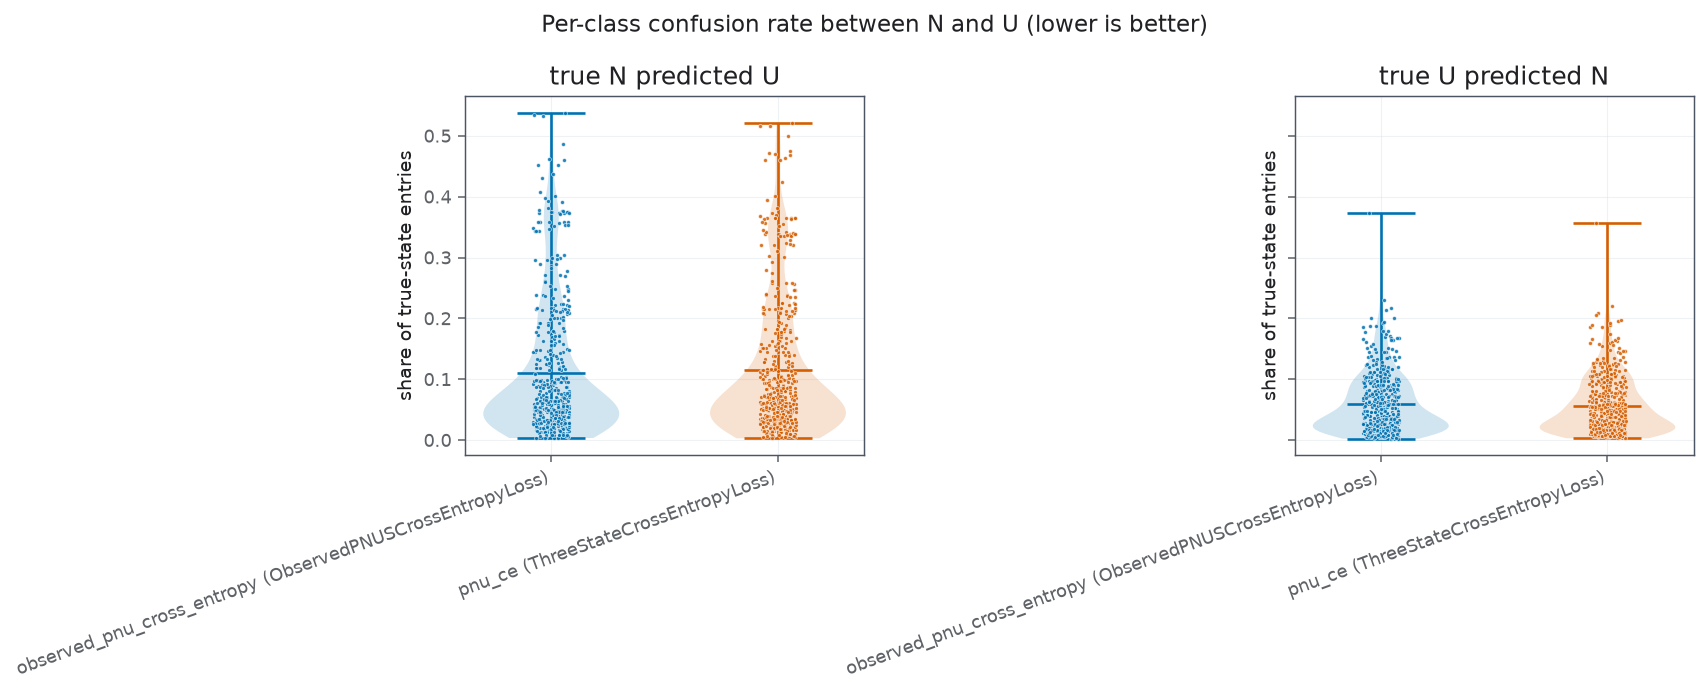

In [8]:
def confusion_share(true_state, predicted_state):
    return (
        state_confusion.query("split == @SPLIT and label in @CONDITION_ORDER and "
                              "true_state == @true_state and predicted_state == @predicted_state")
        .groupby(["label", "class_index", "class_name"], as_index=False)
        .agg(share=("share", "mean"), true_state_total=("true_state_total", "mean"))
    )

n_confused_as_u = confusion_share("N", "U")
u_confused_as_n = confusion_share("U", "N")

figure, (n_axis, u_axis) = plt.subplots(1, 2, figsize=(12.0, 5.0), dpi=theme.figure_dpi, sharey=True)
for position, label in enumerate(CONDITION_ORDER):
    plot_violin_with_points(n_confused_as_u.query("label == @label").share.dropna().to_numpy(), position=position,
                            ax=n_axis, width=0.6, color=LABEL_COLOR[label], point_size=4.0, jitter=0.08, theme=theme)
    plot_violin_with_points(u_confused_as_n.query("label == @label").share.dropna().to_numpy(), position=position,
                            ax=u_axis, width=0.6, color=LABEL_COLOR[label], point_size=4.0, jitter=0.08, theme=theme)
for axis, title in ((n_axis, "true N predicted U"), (u_axis, "true U predicted N")):
    axis.set_xticks(range(len(CONDITION_ORDER)))
    axis.set_xticklabels(CONDITION_ORDER, rotation=20, ha="right")
    axis.set(ylabel="share of true-state entries", title=title)
    axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
figure.suptitle("Per-class confusion rate between N and U (lower is better)")
figure.tight_layout()

In [9]:
CONFUSION_TAIL = 10
worst_n_confusion = n_confused_as_u.sort_values("share", ascending=False).groupby("label").head(CONFUSION_TAIL)
worst_u_confusion = u_confused_as_n.sort_values("share", ascending=False).groupby("label").head(CONFUSION_TAIL)

print(f"Worst {CONFUSION_TAIL} classes, true N predicted U:")
display(worst_n_confusion.set_index(["label", "class_name"])[["share", "true_state_total"]].round(3))
print(f"\nWorst {CONFUSION_TAIL} classes, true U predicted N:")
display(worst_u_confusion.set_index(["label", "class_name"])[["share", "true_state_total"]].round(3))

Worst 10 classes, true N predicted U:


share  \
label                                              class_name                  
observed_pnu_cross_entropy (ObservedPNUSCrossEn... C13H21N3O3|-H    0.538422   
                                                   C9H16O9|-H        0.53401   
                                                   C10H12N4O5|-H    0.533503   
pnu_ce (ThreeStateCrossEntropyLoss)                C13H21N3O3|-H    0.521883   
                                                   C9H16O9|-H       0.516624   
                                                   C10H12N4O5|-H    0.515863   
                                                   C14H26O4|-H           0.5   
observed_pnu_cross_entropy (ObservedPNUSCrossEn... C17H32O2|-H      0.485963   
pnu_ce (ThreeStateCrossEntropyLoss)                C9H10NO3|+Cl     0.474725   
                                                   C18H32O3|-H      0.471354   
                                                   C9H10ClNO3|[M]-  0.471062   
                                                   C17H32O2|-H      0.468696   
                                                   C12H24O3|-H      0.463736   
observed_pnu_cross_entropy (ObservedPNUSCrossEn... C9H10ClNO3|[M]-  0.462271   
                                                   C9H10NO3|+Cl     0.460806   
pnu_ce (ThreeStateCrossEntropyLoss)                C5H13O7P|-H      0.460741   
observed_pnu_cross_entropy (ObservedPNUSCrossEn... C12H24O3|-H      0.452015   
                                                   C12H8O4|-H       0.451661   
                                                   C5H13O7P|-H      0.437037   
                                                   C18H32O3|-H       0.43125   

                                                                   true_state_total  
label                                              class_name                        
observed_pnu_cross_entropy (ObservedPNUSCrossEn... C13H21N3O3|-H              786.0  
                                                   C9H16O9|-H                 788.0  
                                                   C10H12N4O5|-H              788.0  
pnu_ce (ThreeStateCrossEntropyLoss)                C13H21N3O3|-H              786.0  
                                                   C9H16O9|-H                 788.0  
                                                   C10H12N4O5|-H              788.0  
                                                   C14H26O4|-H                541.0  
observed_pnu_cross_entropy (ObservedPNUSCrossEn... C17H32O2|-H                805.0  
pnu_ce (ThreeStateCrossEntropyLoss)                C9H10NO3|+Cl               273.0  
                                                   C18H32O3|-H                192.0  
                                                   C9H10ClNO3|[M]-            273.0  
                                                   C17H32O2|-H                805.0  
                                                   C12H24O3|-H                273.0  
observed_pnu_cross_entropy (ObservedPNUSCrossEn... C9H10ClNO3|[M]-            273.0  
                                                   C9H10NO3|+Cl               273.0  
pnu_ce (ThreeStateCrossEntropyLoss)                C5H13O7P|-H                270.0  
observed_pnu_cross_entropy (ObservedPNUSCrossEn... C12H24O3|-H                273.0  
                                                   C12H8O4|-H                 271.0  
                                                   C5H13O7P|-H                270.0  
                                                   C18H32O3|-H                192.0


Worst 10 classes, true U predicted N:


share  \
label                                              class_name                 
observed_pnu_cross_entropy (ObservedPNUSCrossEn... C9H17NO5|-H     0.374091   
pnu_ce (ThreeStateCrossEntropyLoss)                C9H17NO5|-H      0.35651   
observed_pnu_cross_entropy (ObservedPNUSCrossEn... C15H22O2|-H     0.229985   
pnu_ce (ThreeStateCrossEntropyLoss)                C48H93NO11S|-H  0.221151   
observed_pnu_cross_entropy (ObservedPNUSCrossEn... C16H32O3|-H     0.216905   
                                                   C48H93NO11S|-H  0.213392   
pnu_ce (ThreeStateCrossEntropyLoss)                C46H89NO12S|-H  0.208673   
                                                   C50H75O10P|-H   0.204897   
observed_pnu_cross_entropy (ObservedPNUSCrossEn... C39H73O8P|-H    0.201488   
                                                   C46H89NO12S|-H  0.201314   
pnu_ce (ThreeStateCrossEntropyLoss)                C39H73O8P|-H     0.19814   
                                                   C16H32O3|-H     0.195335   
observed_pnu_cross_entropy (ObservedPNUSCrossEn... C50H90NO10P|-H  0.193672   
                                                   C13H8F2O2|-H    0.192926   
pnu_ce (ThreeStateCrossEntropyLoss)                C50H90NO10P|-H  0.191892   
                                                   C15H22O2|-H     0.189882   
                                                   C49H88NO10P|-H  0.188562   
observed_pnu_cross_entropy (ObservedPNUSCrossEn... C50H89O10P|-H   0.187961   
                                                   C50H75O10P|-H   0.187787   
pnu_ce (ThreeStateCrossEntropyLoss)                C44H85NO12S|-H  0.185774   

                                                                  true_state_total  
label                                              class_name                       
observed_pnu_cross_entropy (ObservedPNUSCrossEn... C9H17NO5|-H              1513.0  
pnu_ce (ThreeStateCrossEntropyLoss)                C9H17NO5|-H              1513.0  
observed_pnu_cross_entropy (ObservedPNUSCrossEn... C15H22O2|-H              1354.0  
pnu_ce (ThreeStateCrossEntropyLoss)                C48H93NO11S|-H           1598.0  
observed_pnu_cross_entropy (ObservedPNUSCrossEn... C16H32O3|-H              2165.0  
                                                   C48H93NO11S|-H           1598.0  
pnu_ce (ThreeStateCrossEntropyLoss)                C46H89NO12S|-H           1522.0  
                                                   C50H75O10P|-H            1654.0  
observed_pnu_cross_entropy (ObservedPNUSCrossEn... C39H73O8P|-H             1075.0  
                                                   C46H89NO12S|-H           1522.0  
pnu_ce (ThreeStateCrossEntropyLoss)                C39H73O8P|-H             1075.0  
                                                   C16H32O3|-H              2165.0  
observed_pnu_cross_entropy (ObservedPNUSCrossEn... C50H90NO10P|-H           1517.0  
                                                   C13H8F2O2|-H             1668.0  
pnu_ce (ThreeStateCrossEntropyLoss)                C50H90NO10P|-H           1517.0  
                                                   C15H22O2|-H              1354.0  
                                                   C49H88NO10P|-H           1224.0  
observed_pnu_cross_entropy (ObservedPNUSCrossEn... C50H89O10P|-H            1329.0  
                                                   C50H75O10P|-H            1654.0  
pnu_ce (ThreeStateCrossEntropyLoss)                C44H85NO12S|-H           1195.0

## Reproducible artifacts

### Methodology

#### Implementation

The measured tables and their provenance are written by the base precompute runner, not
here; this notebook adds `class_discrimination_summary.csv`, a cheap derived aggregation
of tables already in memory.

The results directory is deliberately not versioned: it is regenerable.

### Remarks

### Notes

In [10]:
class_summary.to_csv(RESULTS / "class_discrimination_summary.csv", index=False)
print("derived tables written:", sorted(path.name for path in RESULTS.glob("*.csv")))

derived tables written: ['class_discrimination_summary.csv']


## Results / Summary

### LLM

Executed against the real campaign cache (120 models, 508 classes, 2026-09-14; 15
three-state models across `pnu_ce`/`observed_pnu_cross_entropy`, 5 repetitions x 3
splits each).

**Both conditions genuinely discriminate N, P and U — the decision is not a class-prior
shortcut.** Median per-class `argmax` accuracy is 0.938 for both conditions, against a
median majority-class baseline of 0.611 (always predicting the class's own most common
state) — an average +0.327 absolute gap. Every one of the 508 testable classes is
significant at p<0.05 (uncorrected) for both conditions.

**Pooled confusion (test split, summed over every class and repetition):**

| true state | `pnu_ce` total | correctly kept | `observed_pnu_cross_entropy` total | correctly kept |
|---|---|---|---|---|
| N | 8,146,770 | 92.0% | 4,073,385 | 92.4% |
| P | 1,054,420 | 88.1% | 527,210 | 87.9% |
| U | 12,160,210 | 94.0% | 6,080,105 | 93.8% |

**The N-vs-U confusion this head family exists to avoid is present but modest, and
asymmetric:** pooled, a true N is placed in U about 7.3-7.6% of the time, while a true U
is placed in N about 4.9-5.1% of the time — the head is more likely to mistake a real
negative for "unlabelled" than the reverse. Per class this concentrates unevenly: the
worst N→U confusion classes reach ~45-54% (e.g. `C13H21N3O3|-H`, `C9H16O9|-H`,
`C10H12N4O5|-H`, consistently worst for both conditions — likely low-intensity or
overlapping-isotope ions where "no signal" and "signal but unannotated" are genuinely
hard to tell apart), while the worst U→N confusion classes reach ~19-37% (topped by
`C9H17NO5|-H` for both conditions). `pnu_ce` and `observed_pnu_cross_entropy` behave
almost identically on every measure here and share nearly the same worst-offender
classes — neither condition shows a materially better N/U boundary than the other.

### Person